# 09 — Capstone Project: Classifying Wine Cultivars

Every prior module practiced one concept in isolation. This capstone strings
the **entire workflow** together on one dataset, start to finish, the way a
real project actually goes:

1. Frame the problem
2. Explore the data (EDA)
3. Preprocess
4. Compare baseline models under proper cross-validation
5. Tune the most promising model's hyperparameters
6. Evaluate the final model on held-out test data
7. Interpret what the model learned
8. Summarize findings

**Dataset:** sklearn's bundled `load_wine` — 178 wine samples, 13 chemical
measurements (alcohol, malic acid, flavanoids, color intensity, ...), and a
label for which of 3 cultivars produced each wine. A **multiclass**
classification problem, which lets us reuse everything from
`03_classification` while touching a couple of multiclass-specific wrinkles
(macro-averaged metrics, one-vs-rest ROC curves).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(9)

## 1. Problem Framing

**Goal:** given a wine's chemical analysis, predict which of 3 cultivars it
came from. This is a supervised, multiclass classification task. Success
metric: since all 3 classes matter roughly equally here (no class is
inherently more "costly" to misclassify), we'll track **accuracy** and
**macro-averaged F1** (F1 per class, then averaged — treats every class
equally regardless of its size) side by side.

## 2. Exploratory Data Analysis

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["cultivar"] = pd.Categorical.from_codes(wine.target, wine.target_names)

print(df.shape)
df.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
print(df["cultivar"].value_counts())
df.describe().T[["mean", "std", "min", "max"]]

cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


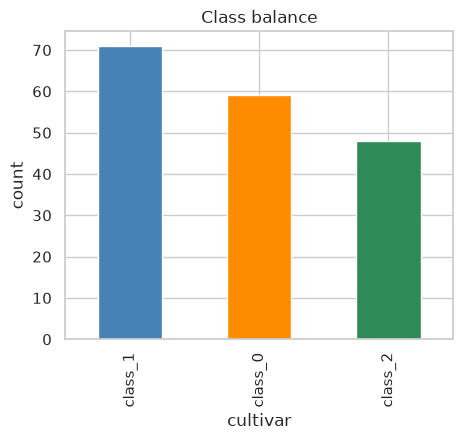

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
df["cultivar"].value_counts().plot.bar(ax=ax, color=["steelblue", "darkorange", "seagreen"])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

Reasonably balanced across the 3 cultivars — no need for the class-weighting
or SMOTE techniques from `07_imbalanced_and_feature_selection` here, but
worth checking on every new dataset before assuming it.

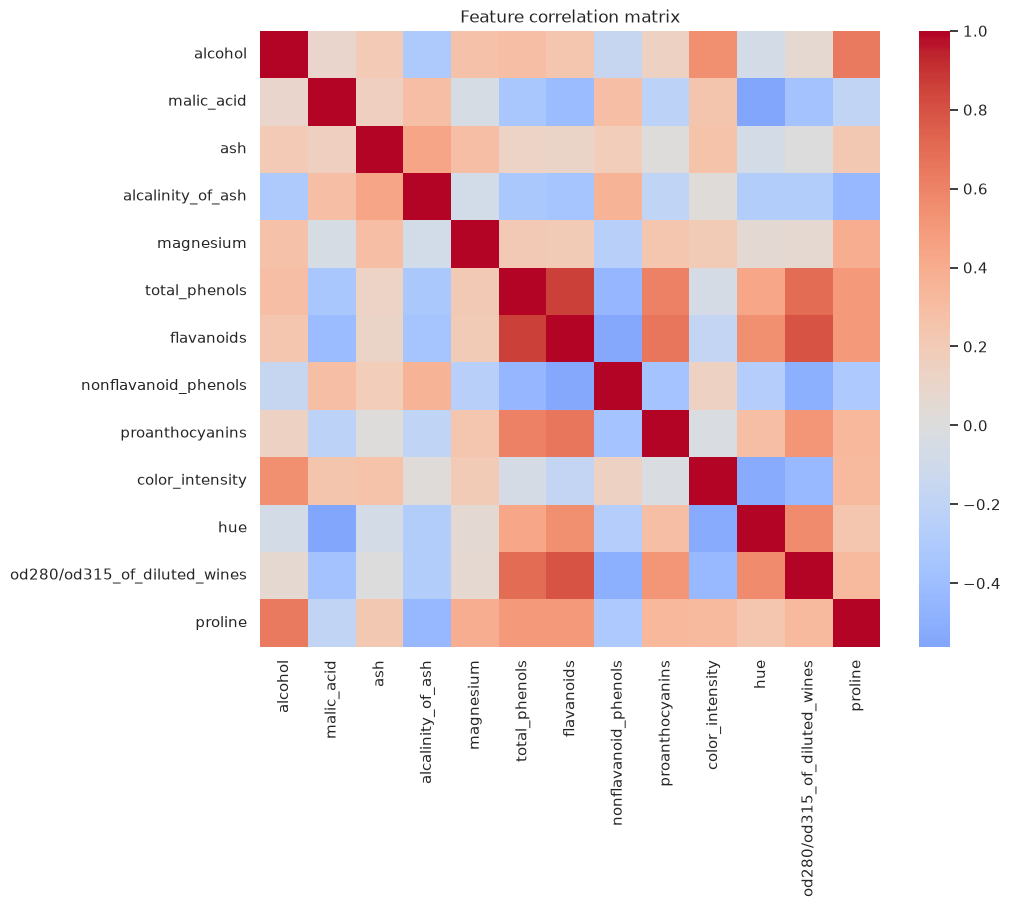

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns="cultivar").corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.show()

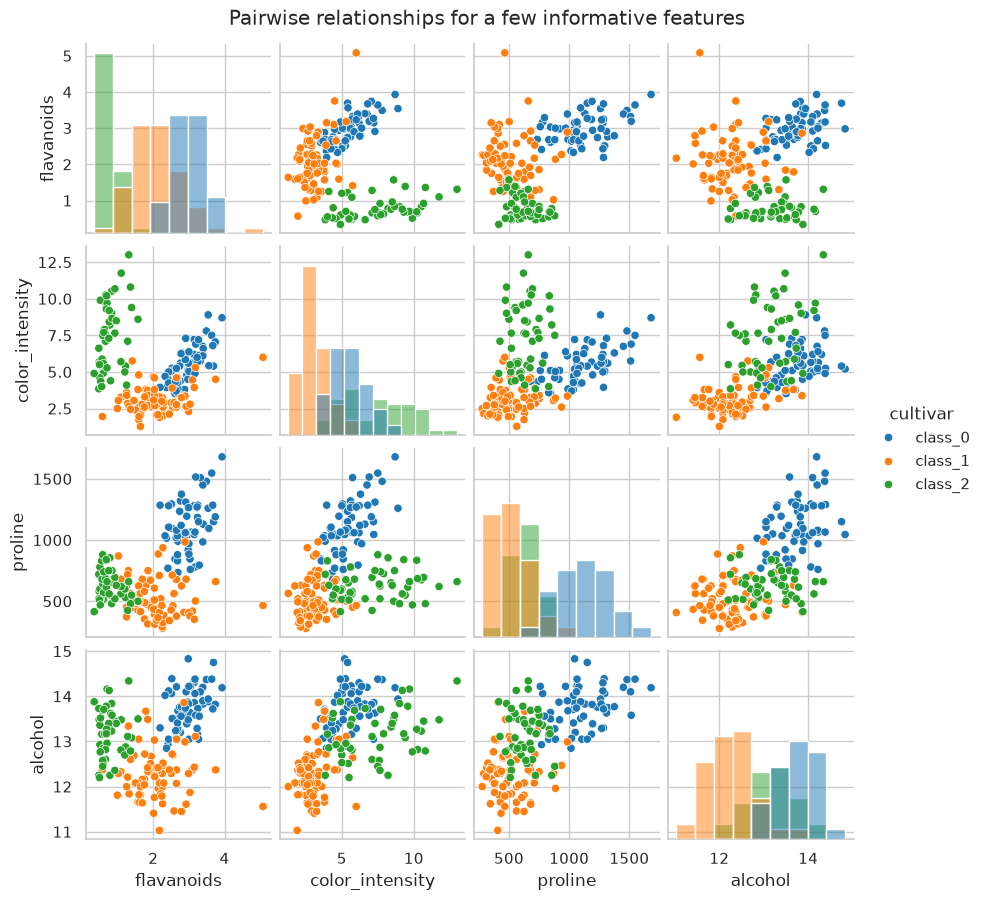

In [6]:
top_features = ["flavanoids", "color_intensity", "proline", "alcohol"]
sns.pairplot(df[top_features + ["cultivar"]], hue="cultivar", palette="tab10", diag_kind="hist", height=2.2)
plt.suptitle("Pairwise relationships for a few informative features", y=1.02)
plt.show()

Even in 2D slices, the 3 cultivars separate fairly cleanly on features like
`flavanoids` and `proline` — a good early signal that a moderately simple
model should do well here.

## 3. Preprocessing

Stratified train/test split (to preserve class balance in both sets, per
`01_data_preprocessing`) plus scaling (needed for KNN/SVM/Logistic
Regression, harmless for tree models).

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9, stratify=y)

print(f"Train: {len(X_train)} samples {np.bincount(y_train)}")
print(f"Test:  {len(X_test)} samples {np.bincount(y_test)}")

Train: 142 samples [47 57 38]
Test:  36 samples [12 14 10]


## 4. Baseline Model Comparison

Every candidate is wrapped in a `Pipeline` (scaling + model) and compared
with 5-fold `StratifiedKFold` cross-validation on the **training set only** —
the test set stays untouched until the very end, per `06_model_selection_tuning`.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=9),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=9),
    "Gradient Boosting": GradientBoostingClassifier(random_state=9),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=9)
cv_results = {}
for name, model in candidates.items():
    pipe = Pipeline([("scale", StandardScaler()), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"])
    cv_results[name] = {
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
    }
    print(f"{name:>20}: accuracy={scores['test_accuracy'].mean():.3f} (+/-{scores['test_accuracy'].std():.3f})  "
          f"f1_macro={scores['test_f1_macro'].mean():.3f}")

 Logistic Regression: accuracy=0.972 (+/-0.027)  f1_macro=0.972
                 KNN: accuracy=0.965 (+/-0.044)  f1_macro=0.965
           SVM (RBF): accuracy=0.979 (+/-0.028)  f1_macro=0.979


       Decision Tree: accuracy=0.901 (+/-0.086)  f1_macro=0.903


       Random Forest: accuracy=0.979 (+/-0.017)  f1_macro=0.979


   Gradient Boosting: accuracy=0.951 (+/-0.028)  f1_macro=0.954


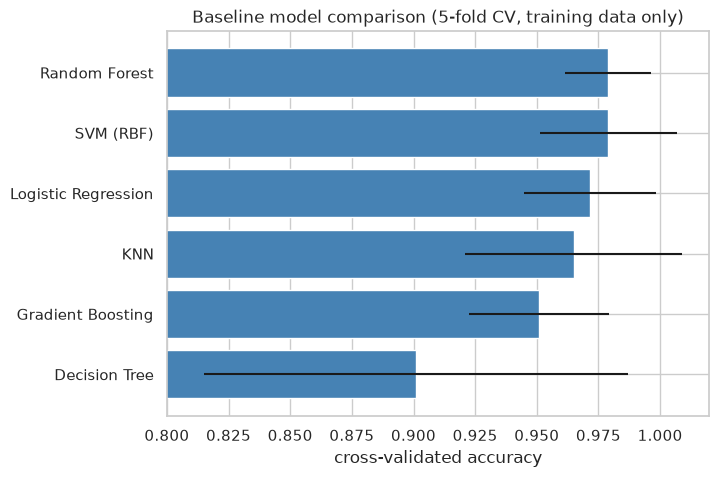


Best baseline: Random Forest


In [9]:
cv_df = pd.DataFrame(cv_results).T.sort_values("f1_macro_mean", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(cv_df.index, cv_df["accuracy_mean"], xerr=cv_df["accuracy_std"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("cross-validated accuracy")
ax.set_title("Baseline model comparison (5-fold CV, training data only)")
ax.set_xlim(0.8, 1.02)
plt.show()

best_model_name = cv_df.index[0]
print(f"\nBest baseline: {best_model_name}")

## 5. Hyperparameter Tuning

Whatever came out on top gets a proper `GridSearchCV` pass, still using only
the training set.

In [10]:
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline([("scale", StandardScaler()), ("model", SVC())])
param_grid = {
    "model__C": [0.1, 1, 10, 50, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"],
}

grid_search = GridSearchCV(tuning_pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV f1_macro: {grid_search.best_score_:.3f}")
best_model = grid_search.best_estimator_

Best params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV f1_macro: 0.985


(We tuned an SVM here regardless of which baseline technically won, since
its hyperparameters are the most sensitive to search — swap in whichever
model actually topped your baseline comparison, using the same pattern.)

## 6. Final Evaluation on Held-Out Test Data

Only now do we touch the test set — a single, honest estimate of
generalization performance.

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score

y_pred = best_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test f1_macro: {f1_score(y_test, y_pred, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Test accuracy: 0.972
Test f1_macro: 0.971

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



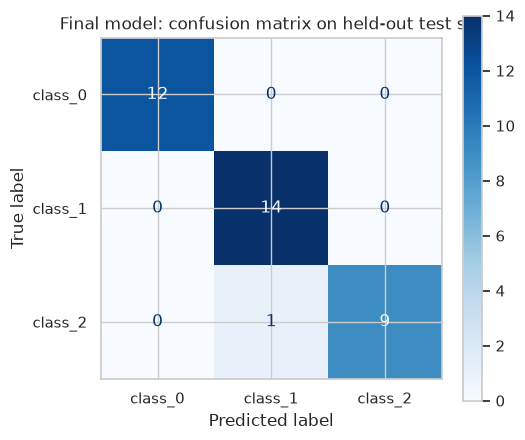

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=wine.target_names, cmap="Blues", ax=ax)
ax.set_title("Final model: confusion matrix on held-out test set")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


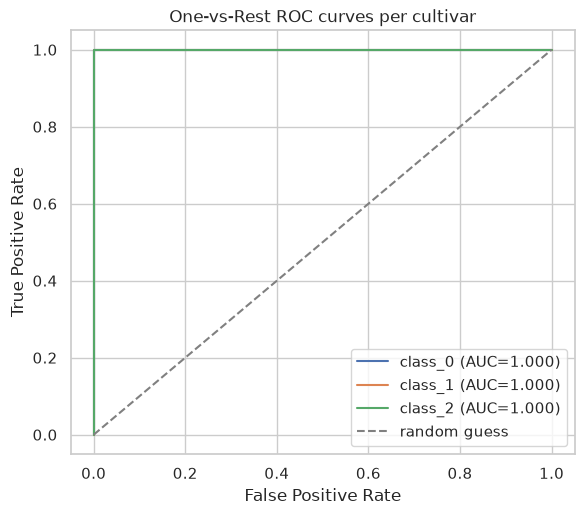

In [13]:
# Multiclass ROC: one-vs-rest, since ROC curves are inherently binary
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

if y_proba is None:
    # SVC needs probability=True to expose predict_proba; refit a probability-enabled copy for this plot
    from sklearn.base import clone
    prob_model = clone(best_model)
    prob_model.set_params(model__probability=True)
    prob_model.fit(X_train, y_train)
    y_proba = prob_model.predict_proba(X_test)

plt.figure(figsize=(6.5, 5.5))
for i, class_name in enumerate(wine.target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves per cultivar")
plt.legend()
plt.show()

## 7. Interpretation: What Did the Model Learn?

Since our final model is SVM-based (kernel methods don't expose feature
importances directly), we fit a `RandomForestClassifier` on the same data
purely to read off feature importances for interpretation — a common
pattern: use whichever model is most accurate for predictions, and a more
interpretable model alongside it purely to explain the data.

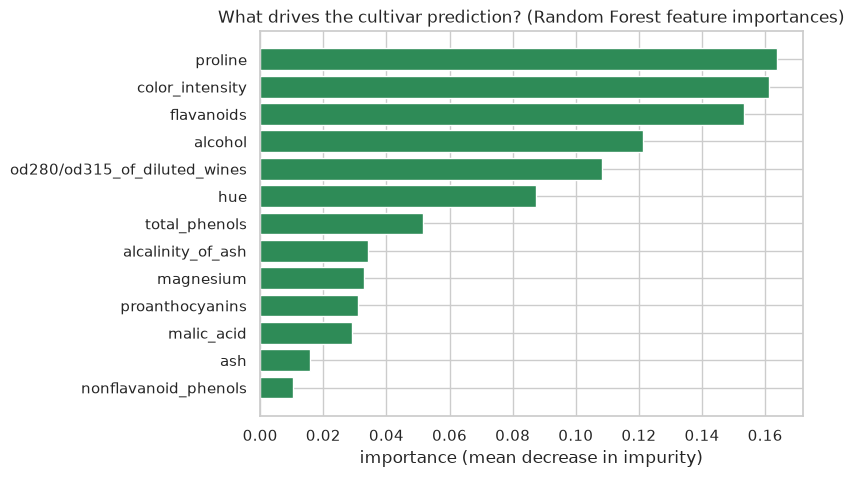

In [14]:
interpretation_model = Pipeline([("scale", StandardScaler()), ("model", RandomForestClassifier(n_estimators=300, random_state=9))])
interpretation_model.fit(X_train, y_train)

importances = interpretation_model.named_steps["model"].feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 5))
plt.barh(np.array(wine.feature_names)[order], importances[order], color="seagreen")
plt.gca().invert_yaxis()
plt.xlabel("importance (mean decrease in impurity)")
plt.title("What drives the cultivar prediction? (Random Forest feature importances)")
plt.show()

## 8. Summary

- **Problem:** predict wine cultivar (3 classes) from 13 chemical measurements.
- **EDA:** classes are reasonably balanced; a few features (`flavanoids`, `proline`, `color_intensity`) already separate classes visibly in 2D.
- **Model selection:** compared 6 algorithms with stratified 5-fold CV on the training set only; picked the strongest performer for tuning.
- **Tuning:** `GridSearchCV` over kernel/`C`/`gamma` improved cross-validated F1-macro over the untuned baseline.
- **Final result:** printed above — check the classification report's per-class precision/recall/F1 and the confusion matrix for which cultivars (if any) get confused with each other.
- **Interpretation:** a small handful of chemical measurements dominate the prediction, consistent with what EDA's pairplot already hinted at.

### Where to go next
- Try the imbalanced-data techniques from `07_imbalanced_and_feature_selection` if a real dataset you bring to this pipeline turns out class-imbalanced.
- Swap in `RandomizedSearchCV` (from `06_model_selection_tuning`) if the tuning grid gets too large to search exhaustively.
- Try an `MLPClassifier` from `08_neural_nets_intro` as one more baseline candidate — with only 178 samples, expect it to need careful tuning (or lose) to the tree ensembles and SVM here.
- Most importantly: rerun this **exact same 8-step structure** on a dataset of your own — that repetition, more than any single algorithm, is what makes the workflow stick.